Hipótese: Com redução de dimensionalidade e agrupamento, melhora-se o desempenho da classificação.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from plotly.graph_objects import Figure, Scatter3d, Cone
from kneed import KneeLocator
from tqdm import tqdm
from math import ceil
from typing import Any, Callable
from matplotlib.axes import Axes
from sklearn.cluster import KMeans
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import GridSearchCV, cross_val_predict, KFold
from sklearn.neighbors import KNeighborsRegressor as kNNRegressor
from sklearn.preprocessing import StandardScaler as Scaler
from sklearn.decomposition import PCA
from sklearn.metrics import (
    r2_score,
    silhouette_score,
    mean_squared_error as MSE,
    confusion_matrix,
    median_absolute_error as MedAE
)
from sklearn.metrics import confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.covariance import MinCovDet

In [2]:
SEED = 42

In [3]:
dataset = {
    'filepath_or_buffer': '../NSQD_v4.02_2015.csv',
    'sep': '|',
    'encoding': 'latin-1',
}

columns = [
    # Hydrological factors
    'Precipitation_Depth_(in)',
    'Runoff_(in)',
    'Days since last rain',

    # Drainage factors
    'Drainage_Area_Acres',
    'Percent_Impervious',

    # Land use
    'Percentage_Residential',
    'Percentage_Commercial',
    'Percentage_Industrial',
    'Percentage_Open_Space',
    'Percentage_Freeway',

    # Target
    'TSS (mg/L)',

    # Context
    'EPA_Rain_Zone',
    'Season',
]

dtype = {
    'Season': 'object',
    'EPA_Rain_Zone': 'Int64',
}

def float_or_nan(value: Any) -> float | type(np.nan):
    try:
        return float(value)
    except ValueError:
        return np.nan

df = pd.read_csv(
    **dataset,
    usecols=columns,
    dtype=dtype,
    na_values=[''],
    converters={col: float_or_nan for col in columns[:-2]},
    nrows=9051
)

df.dropna(axis='index', inplace=True)
df.rename(
    columns={
        'Precipitation_Depth_(in)': 'Precipitation depth (in)',
        'Runoff_(in)': 'Runoff depth (in)',
        'Drainage_Area_Acres': 'Drainage area (Acres)',
        'Percent_Impervious': 'Imperviousness (%)',
        'Percentage_Residential': 'Residential (%)',
        'Percentage_Institutional': 'Institutional (%)',
        'Percentage_Commercial': 'Commercial (%)',
        'Percentage_Industrial': 'Industrial (%)',
        'Percentage_Open_Space': 'Open Space (%)',
        'Percentage_Freeway': 'Freeway (%)',
        'Percentage_Water': 'Water (%)',
        'EPA_Rain_Zone': 'EPA rain zone',
        'Main_Type_Conveyance': 'Main conveyance',
    },
    inplace=True
)

INCH_TO_MM = 25.4
ACRE_TO_M2 = 4046.86

df['Drainage area (km²)'] = (
    df['Drainage area (Acres)'] * ACRE_TO_M2 * 10**3
)
df['Precipitation depth (mm)'] = (
    df['Precipitation depth (in)'] * INCH_TO_MM
)
df['Runoff volume (m³)'] = (
    df['Runoff depth (in)'] * INCH_TO_MM * 10**3
    * df['Drainage area (Acres)'] * ACRE_TO_M2
)

df['Stratification Group'] = (
    df['EPA rain zone'].astype(str) + '_' + df['Season'].astype(str)
)

df.drop(
    columns=[
        'Drainage area (Acres)',
        'Precipitation depth (in)',
        'Runoff depth (in)',
        'EPA rain zone',
        'Season',
    ],
    inplace=True
)

parameters = [
    'Precipitation depth (mm)',
    'Runoff volume (m³)',
    'Drainage area (km²)',
    'Imperviousness (%)',
    'Residential (%)',
    'Commercial (%)',
    'Industrial (%)',
    'Open Space (%)',
    'Freeway (%)',
    'Days since last rain',
]

target = 'TSS (mg/L)'

df.describe()

,Residential (%),Commercial (%),Industrial (%),Open Space (%),Freeway (%),Imperviousness (%),Days since last rain,TSS (mg/L),Drainage area (km²),Precipitation depth (mm),Runoff volume (m³)
count,562.000000,562.000000,562.000000,562.000000,562.000000,562.000000,562.000000,562.000000,5.620000e+02,562.000000,5.620000e+02
mean,27.745018,23.264591,19.720996,8.888434,17.072776,56.365480,11.621343,166.229644,2.190181e+08,17.028124,1.208469e+09
std,41.170640,37.334133,35.969579,19.481193,35.499085,25.250445,22.782389,257.304289,2.628925e+08,12.726055,1.748703e+09
min,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.500000,3.000000,1.618744e+06,0.762000,1.017623e+06
25%,0.000000,0.000000,0.000000,0.000000,0.000000,36.000000,3.120417,39.250000,7.203411e+07,7.874000,1.438395e+08
50%,0.000000,0.000000,0.000000,0.000000,0.000000,60.000000,6.000000,73.500000,1.659213e+08,13.462000,4.961377e+08
75%,80.000000,39.900000,10.800000,7.000000,1.000000,79.300000,12.000000,166.750000,2.642600e+08,22.352000,1.514655e+09
max,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,290.000000,2325.000000,4.532483e+09,99.060000,1.299980e+10


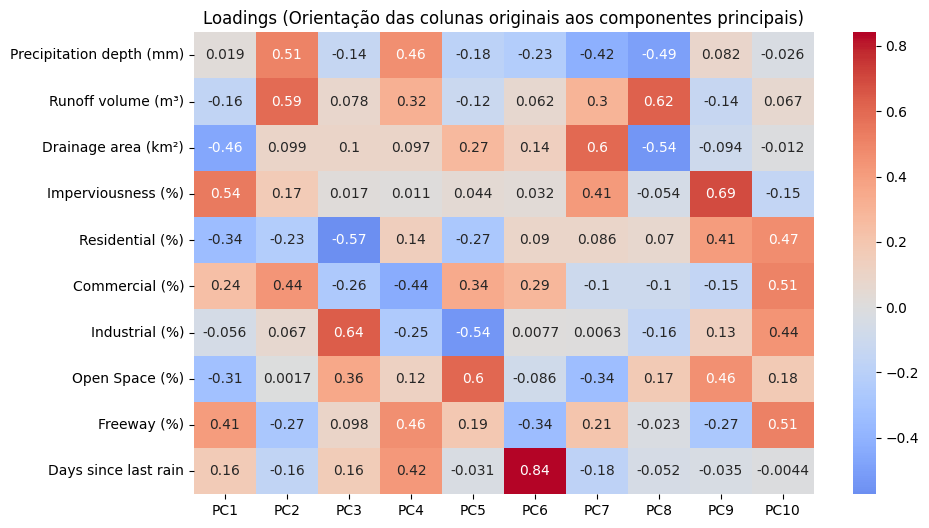

Razão da variância contemplada:
PC1: 24.21%
PC2: 16.64%
PC3: 13.83%
PC4: 11.99%
PC5: 11.43%
PC6: 8.78%
PC7: 6.47%
PC8: 3.63%
PC9: 2.64%
PC10: 0.38%
Total: 100.00%


In [4]:
scaled_values = Scaler().fit_transform(df[parameters])
pca = PCA(n_components=len(parameters))
pca_columns = [f"PC{i}" for i in range(1, len(parameters) + 1)]
pca_scores = pca.fit_transform(scaled_values)

loadings_df = pd.DataFrame(
    pca.components_.T,  # Transpose to align columns with PCs
    columns=pca_columns,
    index=parameters
)

plt.figure(figsize=(10, 6))
sns.heatmap(loadings_df, annot=True, cmap='coolwarm', center=0)
plt.title("Loadings (Orientação das colunas originais aos componentes principais)")
plt.show()
print("Razão da variância contemplada:")
for column, variance_ratio in zip(pca_columns, pca.explained_variance_ratio_):
    print(f"{column}: {variance_ratio * 100:.2f}%")
cumulative_variance = sum(pca.explained_variance_ratio_)
print(f"Total: {cumulative_variance*100:.2f}%")

In [5]:
# Calculate Mahalanobis distance
# Mahalanobis²(x) = (x - μ)ᵀ Σ⁻¹ (x - μ)
# Where:
#
# - x is the data point (vector)
# - μ is the mean vector of the distribution
# - Σ is the covariance matrix
# - Σ⁻¹ is the inverse covariance matrix

# Fit MCD estimator
mcd = MinCovDet(support_fraction=0.75, random_state=SEED)
mcd.fit(pca_scores)

difference = pca_scores - mcd.location_
mahalanobis_dist = np.sqrt(
    np.sum(difference @ mcd.precision_ * difference, axis=1)
)

# Keep samples with lowest Mahalanobis distances (least outliers)
selected_indices = np.argsort(mahalanobis_dist)[:530]

pca_scores = pca_scores[selected_indices]
df = df.iloc[selected_indices]

In [7]:
def NSE(
    y_actual: list[float],
    y_predicted: list[float],
) -> float:
    """Calculates the Nash-Sutcliffe Efficiency."""
    numerator = np.sum((y_actual - y_predicted) ** 2)
    denominador = np.sum((np.mean(y_actual) - y_actual) ** 2)
    return 1 - (numerator / denominador)

def PCA_GridSearch(pca_scores, target_df) -> tuple[int, GridSearchCV | None]:
    # Define the paramters used for all Grid Searches
    cv_folds = 5
    max_k = ceil(len(target_df) * (cv_folds - 1) / cv_folds)
    estimator= Pipeline([
        ('scaler', Scaler()),
        ('knn', kNNRegressor())
    ])
    param_grid = {
        'knn__n_neighbors': range(1, max_k),
        'knn__weights': ['distance']
    }

    # Set initial values for rmse, gs and the number of components
    best_gs = None
    best_components = 0
    best_r2 = 0

    for i in range(1, pca_scores.shape[1]):
        gs = GridSearchCV(
            estimator,
            param_grid,
            cv=KFold(n_splits=cv_folds, shuffle=True, random_state=SEED),
            scoring = 'r2',
            n_jobs=-1,
        )
        gs.fit(pca_scores[:,:i], df[target])
        neg_medae = -gs.best_score_

        # Update rmse and gs values if a better result is achieved
        if gs.best_score_ > best_r2:
            best_r2 = gs.best_score_
            best_gs = gs
            best_components = i
    return best_components, gs
        
n_components, gs = PCA_GridSearch(pca_scores, df[target])
optimal_k = gs.best_params_['knn__n_neighbors']
print("Best component quantity:", n_components)
print("Best k value:", optimal_k)
print(f"Best r2 score: {gs.best_score_}")

Best component quantity: 5
Best k value: 23
Best r2 score: 0.40725426141133936 (mg/L)


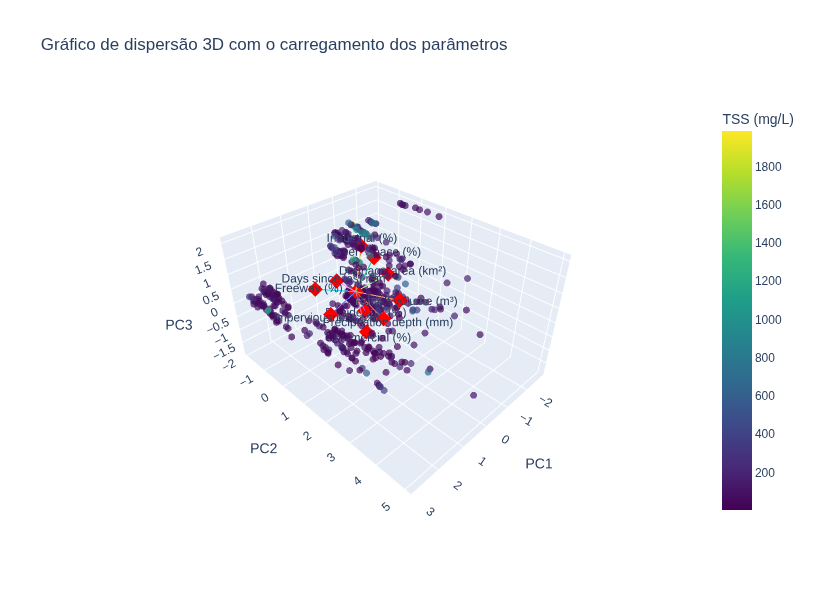

In [8]:
loadings = pca.components_[:3].T
fig = Figure()

# Get the first 3 principal components
pc1 = pca_scores[:, 0]
pc2 = pca_scores[:, 1]
pc3 = pca_scores[:, 2]

# Add data points
fig.add_trace(
    Scatter3d(
        x = pc1,
        y = pc2,
        z = pc3,
        mode='markers',
        marker= {
            'size': 4,
            'color': df[target],
            'colorscale': "Viridis",
            'opacity': 0.7,
            'colorbar': {'title': 'TSS (mg/L)'},
        },
        text= [f'TSS: {val:.1f} mg/L' for val in df[target]],
        showlegend=False,  # ← Remove from legend
        name=''  # Empty name
    )
)

# Add loading arrows
arrow_scale = 2.5
for i, feature in enumerate(parameters):

    # Add arrow line
    fig.add_trace(
        Scatter3d(
            x = [0, loadings[i, 0] * arrow_scale],
            y = [0, loadings[i, 1] * arrow_scale],
            z = [0, loadings[i, 2] * arrow_scale],
            mode = 'lines',
            showlegend = False,
            hoverinfo = 'none',
        )
    )

    # Arrowhead
    fig.add_trace(Scatter3d(
        x=[0, loadings[i, 0] * arrow_scale],
        y=[0, loadings[i, 1] * arrow_scale], 
        z=[0, loadings[i, 2] * arrow_scale],
        mode = 'markers',
        marker = { 'size': 4, 'color': 'red', 'symbol': 'diamond' },
        showlegend = False,
        hoverinfo = 'none'
    ))

    # Feature label
    fig.add_trace(Scatter3d(
        x=[loadings[i, 0] * arrow_scale * 1.15],
        y=[loadings[i, 1] * arrow_scale * 1.15],
        z=[loadings[i, 2] * arrow_scale * 1.15],
        mode='text',
        text=[feature],
        textposition='middle center',
        showlegend=False,
        hoverinfo='none'
    ))

fig.update_layout(
    title = 'Gráfico de dispersão 3D com o carregamento dos parâmetros',
    scene = {
        'xaxis_title': 'PC1',
        'yaxis_title': 'PC2',
        'zaxis_title': 'PC3',
        'camera' : { 'eye': {'x': 1.5, 'y': 1.5, 'z': 1.5} } # Initial view angle
    },
    width=800,
    height=600,
    showlegend=False  # ← Completely remove the legend
)

fig.show()

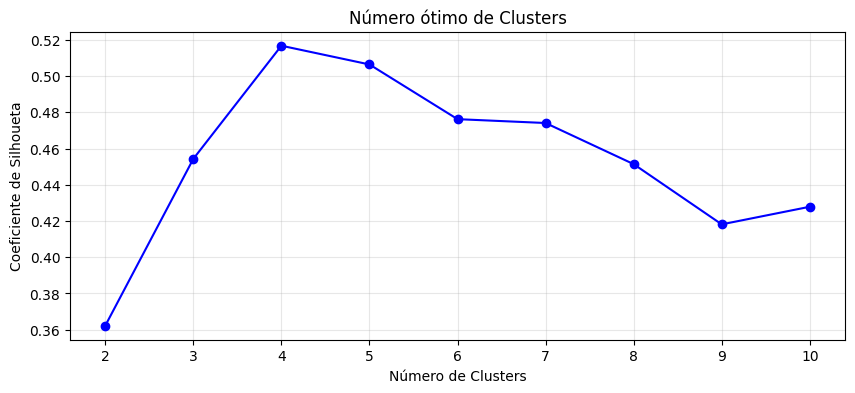

In [9]:
# Use the first 3 principal components for clustering
X_cluster = pca_scores[:, :3]

# Determine optinal number of clusters
silhouette_scores = []
k_range = range(2, 11)
for k in k_range:
    kmeans = KMeans(n_clusters = k, random_state=SEED)
    cluster_labels = kmeans.fit_predict(X_cluster)
    silhouette_scores.append(silhouette_score(X_cluster, cluster_labels))

# Plot silhouette scores to choose optimal k
plt.figure(figsize=(10, 4))
plt.plot(k_range, silhouette_scores, 'bo-')
plt.xlabel('Número de Clusters')
plt.ylabel('Coeficiente de Silhoueta')
plt.title('Número ótimo de Clusters')
plt.grid(True, alpha=0.3)
plt.show()

In [10]:
# Optimal k based on previous inspections
optimal_k = 4
kmeans = KMeans(n_clusters= optimal_k, random_state=SEED, n_init=10)
cluster_labels = kmeans.fit_predict(X_cluster)

df['cluster'] = cluster_labels

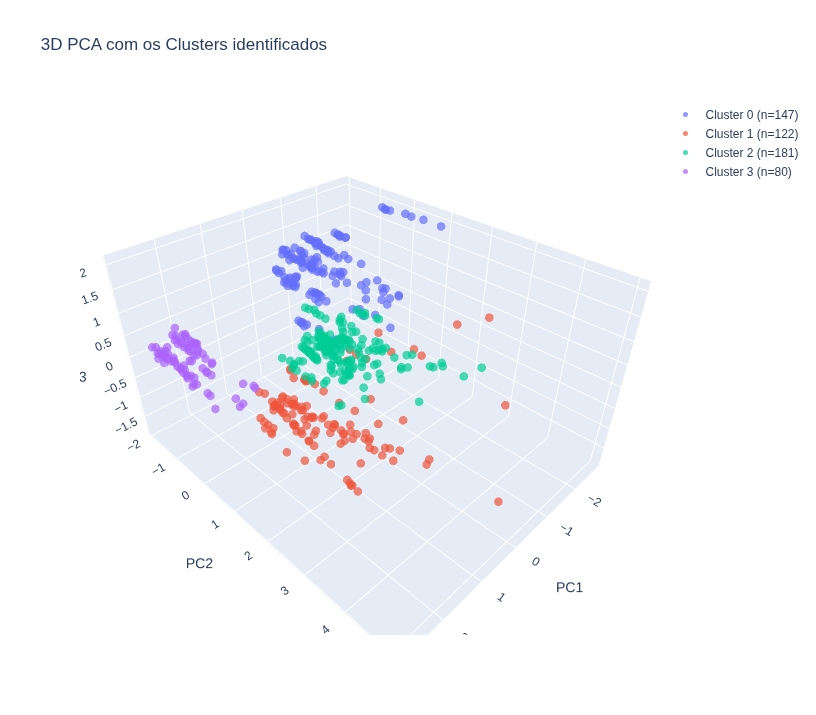

In [11]:
# Create interactive 3D plot with clusters
fig = Figure()

# Color by cluster
for cluster_id in sorted(df['cluster'].unique()):
    mask = df['cluster'] == cluster_id
    count = mask.sum()
    
    fig.add_trace(Scatter3d(
        x=pc1[mask], y=pc2[mask], z=pc3[mask],
        mode='markers',
        marker=dict(
            size=5,
            opacity=0.7
        ),
        name=f'Cluster {cluster_id} (n={count})',  # ← Add count to legend
        text=[f'TSS: {val:.1f} mg/L' for val in df[target][mask]]
    ))

fig.update_layout(
    title='3D PCA com os Clusters identificados',
    scene=dict(
        xaxis_title='PC1',
        yaxis_title='PC2',
        zaxis_title='PC3'
    ),
    width=900,
    height=700
)

fig.show()

In [12]:
cv_folds = 5
estimator = Pipeline([
    ('scaler', Scaler()),
    ('knn', kNNRegressor())
])

# Store results for each cluster
cluster_results = {}
all_predictions = np.zeros_like(df[target], dtype=float)

# Perform cross-validation cluster by cluster
for cluster_id in sorted(df['cluster'].unique()):
    print(f"\n=== Processing Cluster {cluster_id} ===")
    
    # Get data for this cluster only
    cluster_mask = df['cluster'] == cluster_id
    X_cluster = df[parameters][cluster_mask]
    y_cluster = df[target][cluster_mask]
    n_cluster_samples = len(X_cluster)
    
    if n_cluster_samples < cv_folds:
        print(f"  Skipping cluster {cluster_id}: too few samples ({n_cluster_samples}) for {cv_folds}-fold CV")
        continue
    
    # Calculate cluster-specific max_k
    cluster_max_k = ceil(n_cluster_samples * (cv_folds - 1) / cv_folds)
    param_grid = {
        'knn__n_neighbors': range(1, cluster_max_k),
        'knn__weights': ['distance']
    }
    
    print(f"  Cluster size: {n_cluster_samples}, Max k: {cluster_max_k}")
    
    # Grid search for this cluster
    gs = GridSearchCV(
        estimator,
        param_grid,
        cv=KFold(n_splits=cv_folds, shuffle=True, random_state=SEED),
        scoring = 'neg_median_absolute_error',
        n_jobs=-1,
    )
    gs.fit(X_cluster, y_cluster)
    
    # Cross-validation predictions for this cluster
    cv_predictions_cluster = cross_val_predict(
        gs.best_estimator_,
        X_cluster,
        y_cluster,
        cv=KFold(n_splits=cv_folds, shuffle=True, random_state=SEED)
    )
    
    # Store results
    cluster_results[cluster_id] = {
        'X': X_cluster,
        'y_true': y_cluster,
        'y_pred': cv_predictions_cluster,
        'best_k': gs.best_params_['knn__n_neighbors'],
        'best_model': gs.best_estimator_,
        'medae': MedAE(y_cluster, cv_predictions_cluster),
        'r2': gs.best_score_,
        'nse': NSE(y_cluster, cv_predictions_cluster),
        'n_samples': n_cluster_samples,
        'max_k': cluster_max_k
    }
    
    # Store predictions in the full array
    all_predictions[cluster_mask] = cv_predictions_cluster
    print(f"  Best k: {gs.best_params_['knn__n_neighbors']}, "
          f"MedAE: {MedAE(y_cluster, cv_predictions_cluster):.2f}, R²: {gs.best_score_:.3f}")

# Calculate overall metrics
overall_medae = MedAE(df[target], all_predictions)
overall_r2 = r2_score(df[target], all_predictions)
overall_nse = NSE(df[target], all_predictions)

print(f"\n=== OVERALL RESULTS ===")
print(f"Overall MedAE: {overall_medae:.2f} mg/L")
print(f"Overall R²: {overall_r2:.3f}")
print(f"Overall NSE: {overall_nse:.3f}")


=== Processing Cluster 0 ===
  Cluster size: 147, Max k: 118
  Best k: 4, MedAE: 86.55, R²: -95.120

=== Processing Cluster 1 ===
  Cluster size: 122, Max k: 98
  Best k: 4, MedAE: 28.52, R²: -30.211

=== Processing Cluster 2 ===
  Cluster size: 181, Max k: 145
  Best k: 2, MedAE: 32.52, R²: -33.643

=== Processing Cluster 3 ===
  Cluster size: 80, Max k: 64
  Best k: 4, MedAE: 54.51, R²: -52.356

=== OVERALL RESULTS ===
Overall MedAE: 47.59 mg/L
Overall R²: 0.381
Overall NSE: 0.381


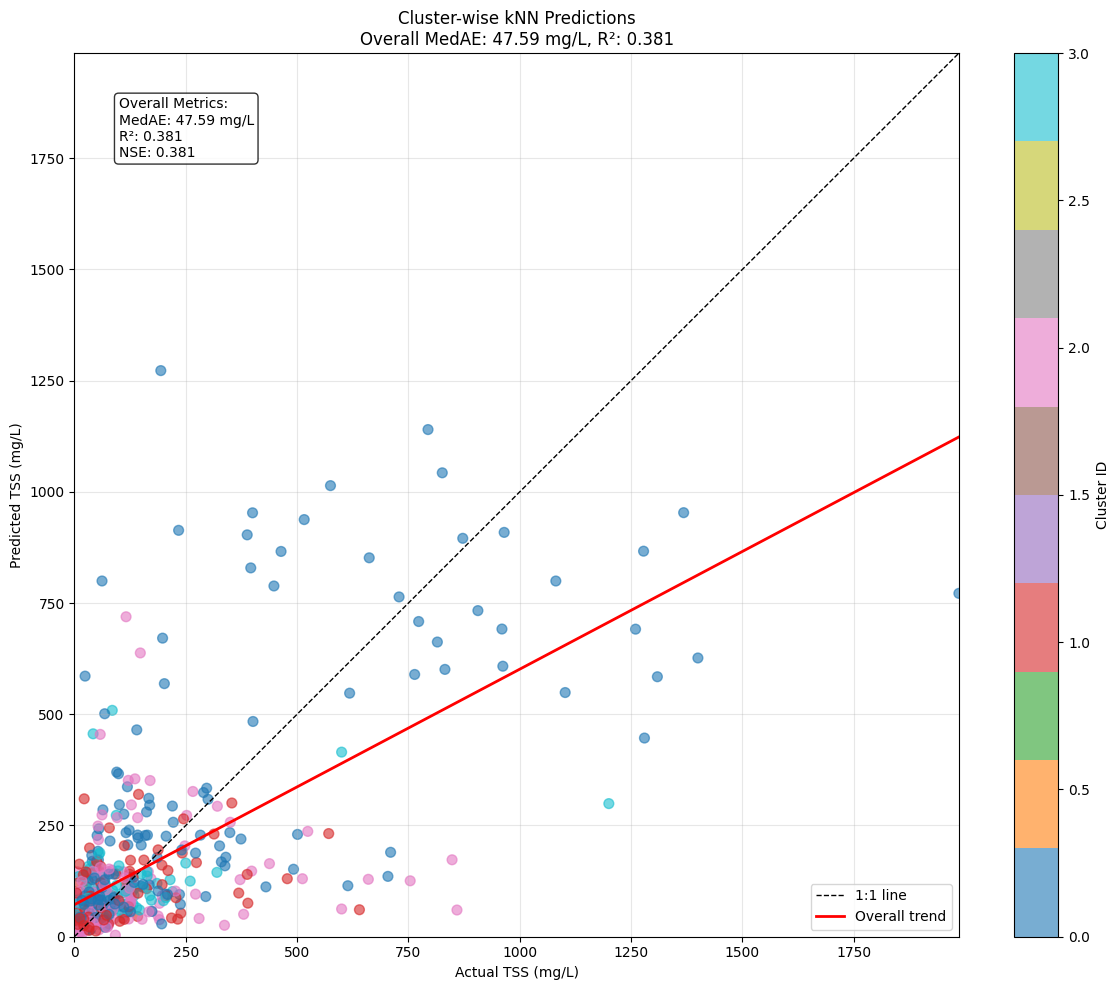

In [13]:
# Create one comprehensive plot colored by cluster
plt.figure(figsize=(12, 10))

# Plot all points colored by cluster
scatter = plt.scatter(df[target], all_predictions, c=df['cluster'], 
                     cmap='tab10', alpha=0.6, s=50)

# 1:1 line
max_val = max(df[target].max(), all_predictions.max())
plt.plot([0, max_val], [0, max_val], 'k--', linewidth=1, label='1:1 line')

# Overall regression line
lr_overall = LinearRegression()
lr_overall.fit(df[target].values.reshape(-1, 1), all_predictions)
x_line = np.linspace(0, max_val, 100)
y_line = lr_overall.predict(x_line.reshape(-1, 1))
plt.plot(x_line, y_line, 'r-', linewidth=2, label='Overall trend')

plt.xlim(0, max_val)
plt.ylim(0, max_val)
plt.xlabel('Actual TSS (mg/L)')
plt.ylabel('Predicted TSS (mg/L)')
plt.title(f'Cluster-wise kNN Predictions\nOverall MedAE: {overall_medae:.2f} mg/L, R²: {overall_r2:.3f}')
plt.grid(True, alpha=0.3)

# Add colorbar
cbar = plt.colorbar(scatter)
cbar.set_label('Cluster ID')

# Add statistics textbox
stats_text = f'Overall Metrics:\nMedAE: {overall_medae:.2f} mg/L\nR²: {overall_r2:.3f}\nNSE: {overall_nse:.3f}'
plt.text(0.05, 0.95, stats_text, transform=plt.gca().transAxes, 
         verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Add cluster-specific info to legend
cluster_info = []
for cluster_id, results in cluster_results.items():
    cluster_info.append(f'Cluster {cluster_id}: k={results["best_k"]}, RMSE={results["medae"]:.1f}')

plt.legend()

plt.tight_layout()
plt.show()

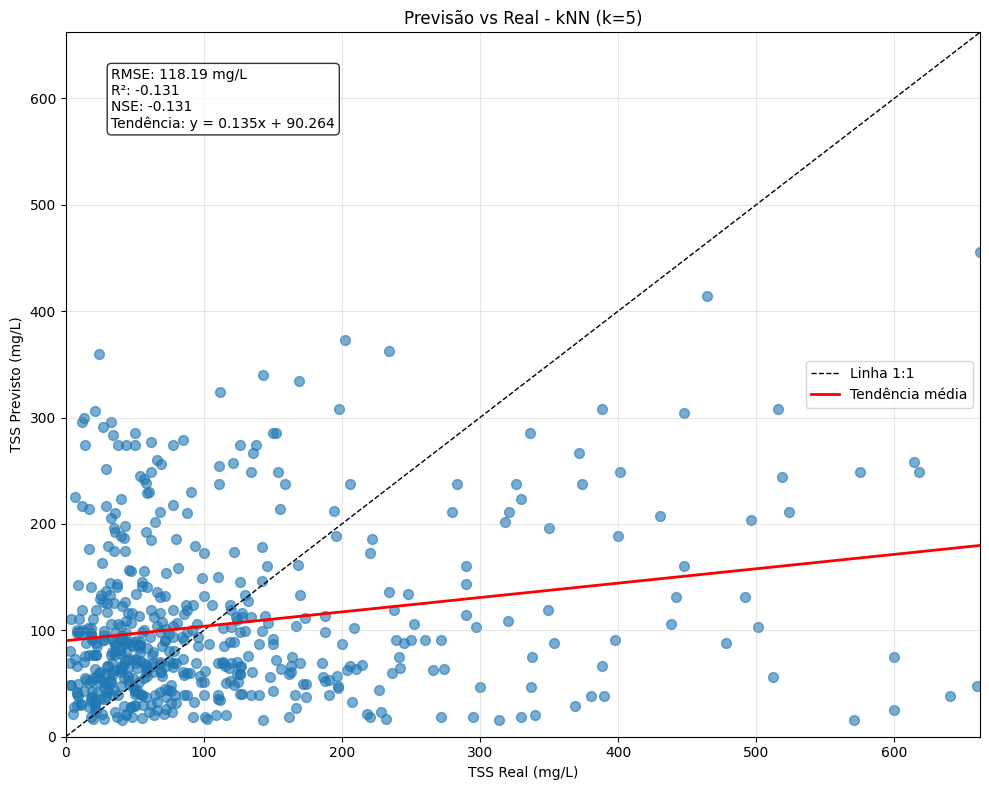

In [11]:
best_model = gs.best_estimator_

cv_predictions = cross_val_predict(
    gs.best_estimator_,
    pca_scores[:, :n_components],
    df[target],
    cv=5
)

# Calculate the maximum value for axis limits
max_real = df[target].max()
max_predicted = cv_predictions.max()
axis_max = max(max_real, max_predicted)

plt.figure(figsize=(10, 8))
plt.scatter(df[target], cv_predictions, alpha=0.6, s=50)

# 1:1 line (perfect prediction)
plt.plot([0, axis_max], [0, axis_max], 'k--', linewidth=1, label='Linha 1:1')

# Regression line (average prediction trend)
# Reshape for sklearn
X_plot = df[target].values.reshape(-1, 1)
y_plot = cv_predictions

# Fit linear regression
lr = LinearRegression()
lr.fit(X_plot, y_plot)

# Generate points for the regression line
x_line = np.linspace(0, axis_max, 100)
y_line = lr.predict(x_line.reshape(-1, 1))

plt.plot(x_line, y_line, 'r-', linewidth=2, label='Tendência média')

plt.xlim(0, axis_max)
plt.ylim(0, axis_max)

plt.xlabel('TSS Real (mg/L)')
plt.ylabel('TSS Previsto (mg/L)')
plt.title(f'Previsão vs Real - kNN (k={optimal_k})')
plt.legend()
plt.grid(True, alpha=0.3)

# Add statistics to the plot
r2 = r2_score(df[target], cv_predictions)
nse = NSE(df[target], cv_predictions)

# Add regression line equation to stats
slope = lr.coef_[0]
intercept = lr.intercept_
plt.text(0.05, 0.95, f'RMSE: {rmse:.2f} mg/L\nR²: {r2:.3f}\nNSE: {nse:.3f}\nTendência: y = {slope:.3f}x + {intercept:.3f}', 
         transform=plt.gca().transAxes, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

In [12]:
cv_folds = 5
max_k = ceil(len(df[target]) * (cv_folds - 1) / cv_folds)
estimator= Pipeline([
    ('scaler', Scaler()),
    ('knn', kNNRegressor())
])
param_grid = {'knn__n_neighbors': range(1, max_k)}

gs = GridSearchCV(
    estimator,
    param_grid,
    cv=KFold(n_splits=cv_folds, shuffle=True, random_state=SEED),
    scoring='neg_mean_squared_error',
    n_jobs=-1,
)
gs.fit(df[parameters], df[target])
rmse = np.sqrt(-gs.best_score_)
print("Best k value:", optimal_k)
print(f"Best RMSE score: {rmse} (mg/L)")

Best k value: 5
Best RMSE score: 117.91264961500632 (mg/L)


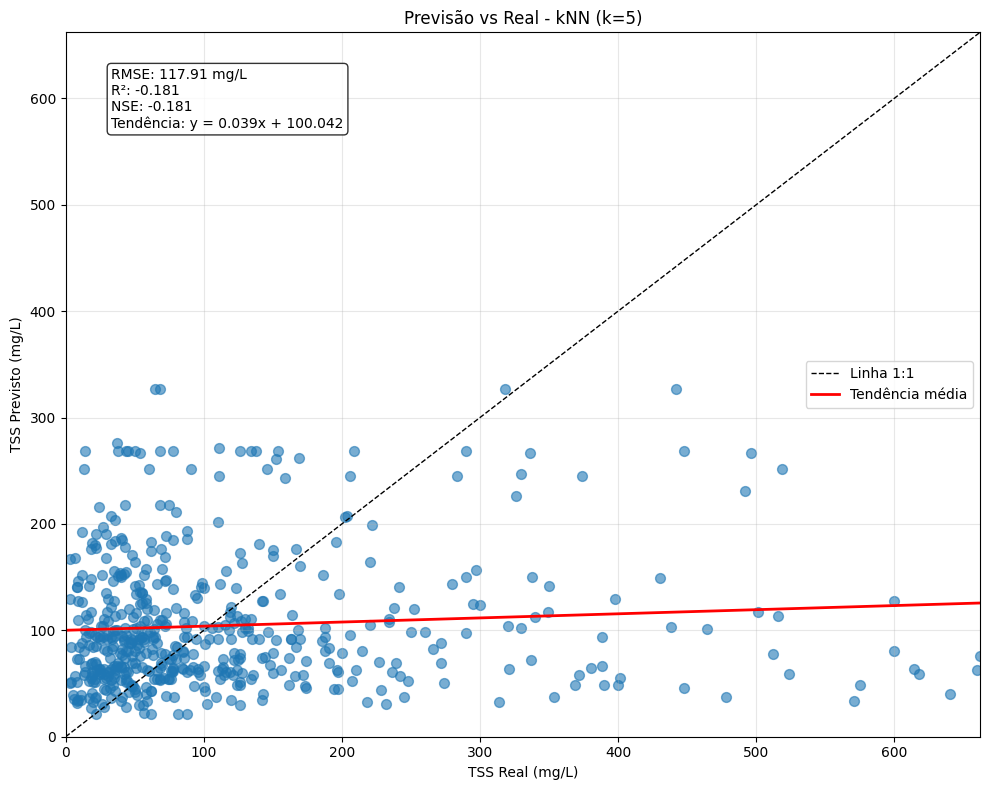

In [13]:
best_model = gs.best_estimator_

cv_predictions = cross_val_predict(
    gs.best_estimator_,
    df[parameters],
    df[target],
    cv=5
)

# Calculate the maximum value for axis limits
max_real = df[target].max()
max_predicted = cv_predictions.max()
axis_max = max(max_real, max_predicted)

plt.figure(figsize=(10, 8))
plt.scatter(df[target], cv_predictions, alpha=0.6, s=50)

# 1:1 line (perfect prediction)
plt.plot([0, axis_max], [0, axis_max], 'k--', linewidth=1, label='Linha 1:1')

# Regression line (average prediction trend)
# Reshape for sklearn
X_plot = df[target].values.reshape(-1, 1)
y_plot = cv_predictions

# Fit linear regression
lr = LinearRegression()
lr.fit(X_plot, y_plot)

# Generate points for the regression line
x_line = np.linspace(0, axis_max, 100)
y_line = lr.predict(x_line.reshape(-1, 1))

plt.plot(x_line, y_line, 'r-', linewidth=2, label='Tendência média')

plt.xlim(0, axis_max)
plt.ylim(0, axis_max)

plt.xlabel('TSS Real (mg/L)')
plt.ylabel('TSS Previsto (mg/L)')
plt.title(f'Previsão vs Real - kNN (k={optimal_k})')
plt.legend()
plt.grid(True, alpha=0.3)

# Add statistics to the plot
r2 = r2_score(df[target], cv_predictions)
nse = NSE(df[target], cv_predictions)

# Add regression line equation to stats
slope = lr.coef_[0]
intercept = lr.intercept_
plt.text(0.05, 0.95, f'RMSE: {rmse:.2f} mg/L\nR²: {r2:.3f}\nNSE: {nse:.3f}\nTendência: y = {slope:.3f}x + {intercept:.3f}', 
         transform=plt.gca().transAxes, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()